# Module 1 — Solutions to the Exercises
### DeepSets, PFN & EFN · *Sets, Graphs & Symmetry for High-Energy Physics* (TIFR ML School 2026)

This notebook works through **all five exercises** at the end of
`Module1_DeepSets_PFN_EFN.ipynb`. It is **self-contained**: the *Setup* section below re-imports the
libraries, reloads the JetClass data, and re-defines the DeepSets/PFN/EFN building blocks from the
module, so you can run this notebook on its own.

| # | Exercise | Idea it drives home |
|---|----------|---------------------|
| 1 | **Pooling matters** | `mean` forgets multiplicity; the Deep Sets theorem is stated with `sum` for a reason |
| 2 | **Jet-mass regression** | DeepSets is not just a classifier — the same pool regresses a physical observable |
| 3 | **Multiclass** | one head, four jet types; the confusion matrix is *physics* |
| 4 | **IRC-safety in practice** | the EFN is flat *by construction*; how far does the trained PFN actually drift? |
| 5 | **Attention pooling** | a learned, permutation-invariant pool = a one-line Set-Transformer teaser for Module 3 |

Each section restates the problem, explains the approach and the physics/ML behind it, gives runnable
code, and closes with a short discussion of what the numbers mean.

> **Speed knobs.** `N_PER_GRP`, `MAX_PART` and the per-exercise `epochs` trade accuracy for runtime.
> The defaults train in a few minutes on a laptop (CPU / Apple-MPS). Raise them to sharpen every effect.

## Setup — imports, data, and the Module-1 building blocks

Nothing new here: this is the machinery from Module 1, gathered in one place. We load a **balanced,
four-group** JetClass sample (QCD, Higgs, W/Z, top) *once* — that single sample feeds the multiclass
exercise (§3) and the mass-regression exercise (§2), and we carve the **top-vs-QCD** binary subset out
of it for the IRC (§4) and attention-pooling (§5) exercises.

In [1]:
import os, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(0); np.random.seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


In [2]:
# --- Module-1 building blocks (verbatim) -------------------------------------------------
def make_mlp(in_dim, hidden, out_dim, act=nn.ReLU):
    dims = [in_dim, *hidden]; layers = []
    for a, b in zip(dims[:-1], dims[1:]):
        layers += [nn.Linear(a, b), act()]
    layers += [nn.Linear(dims[-1], out_dim)]
    return nn.Sequential(*layers)

def masked_sum(x, mask):    # x:(B,N,C) mask:(B,N)
    return (x * mask.unsqueeze(-1)).sum(dim=1)

def masked_mean(x, mask):
    return masked_sum(x, mask) / mask.sum(dim=1, keepdim=True).clamp(min=1.0)

class DeepSetsClassifier(nn.Module):
    """Canonical Deep Sets / PFN:  out = F( pool_i Phi(x_i) ).  (n_classes=1 => regression head.)"""
    def __init__(self, in_features, phi_hidden=(64, 128, 128), latent=128,
                 f_hidden=(128, 64), n_classes=2, pool="sum"):
        super().__init__()
        self.pool = pool
        self.phi  = make_mlp(in_features, phi_hidden, latent)
        self.f    = make_mlp(latent, f_hidden, n_classes)
    def forward(self, x, mask):
        h = self.phi(x)
        z = masked_sum(h, mask) if self.pool == "sum" else masked_mean(h, mask)
        return self.f(z)

class EFN(nn.Module):
    """Energy Flow Network (IRC-safe):  F( sum_i z_i * Phi(angles_i) )."""
    def __init__(self, n_angle=2, phi_hidden=(64, 128, 128), latent=128,
                 f_hidden=(128, 64), n_classes=2):
        super().__init__()
        self.phi = make_mlp(n_angle, phi_hidden, latent)
        self.f   = make_mlp(latent, f_hidden, n_classes)
    def forward(self, angles, z, mask):
        h = self.phi(angles)
        w = (z * mask).unsqueeze(-1)
        return self.f((w * h).sum(dim=1))

def background_rejection(y, p, target_eff=0.5):
    fpr, tpr, _ = roc_curve(y, p)
    return 1.0 / max(np.interp(target_eff, tpr, fpr), 1e-12)

In [3]:
# --- Locate + load the JetClass example file --------------------------------------------
import uproot, awkward as ak

CANDIDATE_PATHS = [
    "../data/JetClass_example_100k.root",
    "/Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root",
    "./JetClass_example_100k.root",
]
root_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if root_path is None:
    raise FileNotFoundError("JetClass_example_100k.root not found; searched:\n  " + "\n  ".join(CANDIDATE_PATHS))
print("Using:", root_path)

MAX_PART   = 128     # pad / truncate every jet to this many particles
N_PER_GRP  = 4000    # jets per GROUP (QCD, H, V, top); raise for accuracy, lower for speed

tree = uproot.open(root_path)["tree"]
LABELS10 = ["label_QCD","label_Hbb","label_Hcc","label_Hgg","label_H4q","label_Hqql",
            "label_Zqq","label_Wqq","label_Tbqq","label_Tbl"]
br = tree.arrays(["part_px","part_py","part_pz","part_energy","part_deta","part_dphi",
                  "jet_sdmass","jet_pt"] + LABELS10)

Using: /Users/sanmay/Documents/ML_SCHOOLS/MLSCHOOL_2023_ICTS/Main_School/JetDataset/JetClass_example_100k.root


In [4]:
# --- Build a balanced 4-group sample: 0=QCD, 1=Higgs, 2=W/Z (V), 3=top -------------------
onehot = np.stack([ak.to_numpy(br[k]).astype(bool) for k in LABELS10], axis=1)  # (Njet,10)
GROUPS = {
    0: ["label_QCD"],
    1: ["label_Hbb","label_Hcc","label_Hgg","label_H4q","label_Hqql"],
    2: ["label_Zqq","label_Wqq"],
    3: ["label_Tbqq","label_Tbl"],
}
GROUP_NAMES = ["QCD", "H", "W/Z", "top"]
col = {k: i for i, k in enumerate(LABELS10)}

rng = np.random.default_rng(0)
sel, y4 = [], []
for g, keys in GROUPS.items():
    in_g = np.any(onehot[:, [col[k] for k in keys]], axis=1)
    idx = np.where(in_g)[0]
    idx = rng.permutation(idx)[:N_PER_GRP]
    sel.append(idx); y4.append(np.full(len(idx), g))
    print(f"group {g} ({GROUP_NAMES[g]:>4}): {len(idx)} jets")
sel = np.concatenate(sel); y4 = np.concatenate(y4).astype(np.int64)

# per-particle kinematics for the selected jets (still jagged)
px, py, pz, e = br["part_px"][sel], br["part_py"][sel], br["part_pz"][sel], br["part_energy"][sel]
deta, dphi    = br["part_deta"][sel], br["part_dphi"][sel]
sdmass = ak.to_numpy(br["jet_sdmass"][sel]).astype(np.float32)   # target for the regression exercise

group 0 ( QCD): 4000 jets
group 1 (   H): 4000 jets
group 2 ( W/Z): 4000 jets
group 3 ( top): 4000 jets


In [5]:
# --- The 7 Module-1 per-particle features + EFN inputs (angles, energy fraction) ---------
pt = np.sqrt(px**2 + py**2); dR = np.sqrt(deta**2 + dphi**2)
sumpt = ak.sum(pt, axis=1); sume = ak.sum(e, axis=1)
FEATURE_NAMES = ["deta","dphi","log_pt","log_e","log_pt_rel","log_e_rel","dR"]
feat_list = [deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
             np.log(pt/sumpt+1e-8), np.log(e/sume+1e-8), dR]

def pad_feature(f):
    return ak.to_numpy(ak.fill_none(ak.pad_none(f, MAX_PART, clip=True), 0.0))

X      = np.stack([pad_feature(f) for f in feat_list], axis=-1).astype(np.float32)  # (Njet,MAX_PART,7)
nparts = np.minimum(ak.to_numpy(ak.num(pt, axis=1)), MAX_PART)
mask   = (np.arange(MAX_PART)[None, :] < nparts[:, None]).astype(np.float32)
angles = np.stack([pad_feature(deta), pad_feature(dphi)], axis=-1).astype(np.float32)
zfrac  = pad_feature(pt/sumpt).astype(np.float32)
print("X:", X.shape, " mask:", mask.shape, " angles:", angles.shape, " sdmass:", sdmass.shape)

X: (16000, 128, 7)  mask: (16000, 128)  angles: (16000, 128, 2)  sdmass: (16000,)


In [6]:
# --- Tensors, a shuffled 70/15/15 split, and TRAIN-statistics standardization ------------
Xt      = torch.from_numpy(X)
Mt      = torch.from_numpy(mask)
Y4      = torch.from_numpy(y4)
AnglesT = torch.from_numpy(angles)
Zt      = torch.from_numpy(zfrac)
SDt     = torch.from_numpy(sdmass)

g = torch.Generator().manual_seed(0)
perm = torch.randperm(len(Y4), generator=g)
Xt, Mt, Y4, AnglesT, Zt, SDt = Xt[perm], Mt[perm], Y4[perm], AnglesT[perm], Zt[perm], SDt[perm]

n = len(Y4); n_tr, n_va = int(0.70*n), int(0.15*n)
sl = {"train": slice(0, n_tr), "val": slice(n_tr, n_tr+n_va), "test": slice(n_tr+n_va, n)}

flat = Xt[sl["train"]][Mt[sl["train"]].bool()]
feat_mean, feat_std = flat.mean(0), flat.std(0).clamp(min=1e-6)
Xt = (Xt - feat_mean) / feat_std     # padded slots become non-zero but masked pooling drops them
print("standardized train means ~0:", Xt[sl['train']][Mt[sl['train']].bool()].mean(0).numpy().round(2))

# Binary top-vs-QCD view (labels 0=QCD, 3=top -> 0/1) used by §4 and §5
binmask = (Y4 == 0) | (Y4 == 3)
Yb = (Y4 == 3).long()                # 1 = top, 0 = QCD
print("binary top-vs-QCD jets:", int(binmask.sum().item()))

standardized train means ~0: [ 0.  0. -0. -0.  0.  0.  0.]
binary top-vs-QCD jets: 8000


In [7]:
# --- Tiny dataset/loader + generic train loop (shared by all exercises) ------------------
class TensorSet(Dataset):
    def __init__(self, tensors): self.tensors = tensors
    def __len__(self): return len(self.tensors[0])
    def __getitem__(self, i): return tuple(t[i] for t in self.tensors)

def loaders_from(tensors_by_split, bs=256):
    return {k: DataLoader(TensorSet(t), batch_size=bs, shuffle=(k == "train"))
            for k, t in tensors_by_split.items()}

def train_classifier(model, loaders, forward, epochs=8, lr=1e-3, n_out=2, quiet=False):
    """forward(model, batch)->(logits, y). Reports val AUC (binary) or accuracy (multiclass)."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        for batch in loaders["train"]:
            batch = [b.to(device) for b in batch]
            logits, y = forward(model, batch)
            loss = F.cross_entropy(logits, y)
            opt.zero_grad(); loss.backward(); opt.step()
        if not quiet:
            m = eval_classifier(model, loaders["val"], forward, n_out)
            extra = f"AUC {m['auc']:.4f}" if n_out == 2 else f"acc {m['acc']:.4f}"
            print(f"  epoch {ep+1:2d}: val loss {m['loss']:.3f}  {extra}")
    return model

@torch.no_grad()
def eval_classifier(model, loader, forward, n_out=2):
    model.eval(); ys, ps, loss_sum, ntot = [], [], 0.0, 0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        logits, y = forward(model, batch)
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item(); ntot += y.size(0)
        ys.append(y.cpu()); ps.append(F.softmax(logits, -1).cpu())
    y = torch.cat(ys).numpy(); p = torch.cat(ps).numpy()
    out = {"loss": loss_sum/ntot, "y": y, "prob": p, "pred": p.argmax(1),
           "acc": (p.argmax(1) == y).mean()}
    if n_out == 2:
        out["auc"] = roc_auc_score(y, p[:, 1]); out["p1"] = p[:, 1]
    return out

print("Setup complete.")

Setup complete.


## Exercise 1 — Pooling matters

> *Re-train the warm-up classifier with `pool="mean"`. Then construct two point clouds that
> `mean`-pooling cannot tell apart but `sum`-pooling can (hint: duplicate every point). What does this
> say about the Deep Sets theorem's preference for the sum?*

**The concept.** Deep Sets says an invariant function is `ρ(⊕_i φ(x_i))` for a symmetric pool `⊕`.
The theorem is proved with the **sum**. `mean` and `max` are *also* permutation-invariant, so they give
valid Deep Sets — but they are **lossy**:

- **`mean` throws away the multiplicity `N`.** `mean({x}) = mean({x, x, …, x})`. A jet with 10 identical
  prongs and a jet with 100 looks the same after mean-pooling.
- **`max` throws away everything but the coordinate-wise extremes.**

The sum keeps both the *shape* of the set and *how many* points it has (it is `N × mean`). Below we
(a) train the image classifier with `sum` and with `mean` and compare accuracy, then (b) build the exact
counterexample the hint asks for: **a cloud and its point-doubled copy**, which are *provably identical*
to a mean-pool network and *provably different* to a sum-pool network.

In [8]:
# Image point-cloud warm-up (from Module 1 §5), needed only for this exercise.
from torchvision import datasets, transforms

def load_image_dataset(root="../data", train=True):
    tfm = transforms.ToTensor()
    try:
        return datasets.MNIST(root, train=train, download=True, transform=tfm), "MNIST"
    except Exception as ex:
        print("MNIST unavailable (", ex, ") -> FashionMNIST")
        return datasets.FashionMNIST(root, train=train, download=True, transform=tfm), "FashionMNIST"

def image_to_pointcloud(img, threshold=0.0):
    a = img[0]; ys, xs = torch.where(a > threshold); H, W = a.shape
    return torch.stack([xs.float()/W, ys.float()/H, a[ys, xs]], dim=-1)

class PointCloudImages(Dataset):
    def __init__(self, root="../data", train=True, max_points=200):
        self.ds, self.name = load_image_dataset(root, train); self.max_points = max_points
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx):
        img, label = self.ds[idx]; pts = image_to_pointcloud(img)
        if pts.shape[0] > self.max_points:
            pts = pts[torch.argsort(pts[:, 2], descending=True)[:self.max_points]]
        return pts, label

def pad_collate(batch):
    clouds, labels = zip(*batch); N = max(c.shape[0] for c in clouds)
    B, Cd = len(clouds), clouds[0].shape[1]
    x = torch.zeros(B, N, Cd); m = torch.zeros(B, N)
    for i, c in enumerate(clouds):
        x[i, :c.shape[0]], m[i, :c.shape[0]] = c, 1.0
    return x, m, torch.tensor(labels)

train_ds = Subset(PointCloudImages("../data", train=True),  range(20000))
test_ds  = Subset(PointCloudImages("../data", train=False), range(5000))
img_loaders = {"train": DataLoader(train_ds, 128, shuffle=True,  collate_fn=pad_collate),
               "test":  DataLoader(test_ds, 256, shuffle=False, collate_fn=pad_collate)}

In [9]:
def train_image_model(pool, epochs=5):
    torch.manual_seed(0)
    model = DeepSetsClassifier(in_features=3, n_classes=10, pool=pool).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for ep in range(epochs):
        model.train()
        for x, m, y in img_loaders["train"]:
            x, m, y = x.to(device), m.to(device), y.to(device)
            loss = F.cross_entropy(model(x, m), y)
            opt.zero_grad(); loss.backward(); opt.step()
    # test accuracy
    model.eval(); correct = total = 0
    with torch.no_grad():
        for x, m, y in img_loaders["test"]:
            x, m, y = x.to(device), m.to(device), y.to(device)
            correct += (model(x, m).argmax(-1) == y).sum().item(); total += y.size(0)
    return model, correct/total

model_sum,  acc_sum  = train_image_model("sum")
model_mean, acc_mean = train_image_model("mean")
print(f"\nTest accuracy   sum-pool: {acc_sum:.3f}    mean-pool: {acc_mean:.3f}")


Test accuracy   sum-pool: 0.729    mean-pool: 0.505


In [10]:
# The counterexample: a cloud A vs. its point-DOUBLED copy A2 (every point repeated twice).
# mean(A) == mean(A2)  ->  a mean-pool net cannot tell them apart.
# sum(A2) == 2*sum(A)  ->  a sum-pool net generally CAN.
x, m, y = next(iter(img_loaders["test"]))
A  = x[:1].to(device); Am = m[:1].to(device)                 # one point cloud (padded)
n1 = int(Am.sum())
pts = A[:, :n1, :]                                           # its real points, shape (1,n1,3)
A2  = torch.cat([pts, pts], dim=1)                           # duplicate every point -> (1,2*n1,3)
A2m = torch.ones(1, 2*n1, device=device)

with torch.no_grad():
    for name, mdl in [("mean-pool", model_mean), ("sum-pool", model_sum)]:
        o1 = F.softmax(mdl(pts, torch.ones(1, n1, device=device)), -1)
        o2 = F.softmax(mdl(A2, A2m), -1)
        print(f"{name:9s}:  max|p(A) - p(A_doubled)| = {(o1-o2).abs().max().item():.2e}"
              f"   pred(A)={o1.argmax().item()} pred(A2)={o2.argmax().item()}")
print("\nmean-pool: outputs identical to fp precision (it literally cannot see the doubling).")
print("sum-pool : outputs differ (the sum encodes multiplicity).")

mean-pool:  max|p(A) - p(A_doubled)| = 8.94e-08   pred(A)=7 pred(A2)=7
sum-pool :  max|p(A) - p(A_doubled)| = 1.21e-01   pred(A)=7 pred(A2)=7

mean-pool: outputs identical to fp precision (it literally cannot see the doubling).
sum-pool : outputs differ (the sum encodes multiplicity).


**What this shows.** The mean-pool network gives *bit-for-bit identical* predictions for a cloud and its
doubled copy — the multiplicity information never reached `ρ`. The sum-pool network sees a different pooled
vector and responds. On this task the **sum pool trains to noticeably higher accuracy**: the total amount of
"ink" (how many pixels are lit) is itself a digit cue, and mean-pooling throws it away. When multiplicity /
total is *not* informative, `mean` is a fine — and sometimes more stable — default. But in HEP
**multiplicity is discriminating** — QCD jets carry systematically more soft particles than boosted-object
jets — so the theorem's canonical `sum` (or concatenating `sum ⊕ mean`) is the safe choice. The lesson:
*every* symmetric pool is a valid Deep Set, but they are not equally **expressive**, and the sum is the one
the theorem is built on.

## Exercise 2 — Jet-mass regression

> *Replace the classifier head with a single regression output and train the PFN to predict the jet
> (soft-drop) mass. Use an MSE loss; report the resolution. Which features matter most?*

**The concept.** DeepSets is a general set→vector map; nothing forces the output to be a class. Here we
regress the **soft-drop jet mass** `jet_sdmass` — a real physical observable and, in fact, one of the most
powerful single variables for tagging boosted W/Z/H/top (their masses cluster near the parent-particle
mass, QCD's does not). Two practical points:

1. **Standardize the target.** Masses span 0–200+ GeV; we train on `(m − μ)/σ` and invert for reporting,
   which keeps the MSE well-conditioned.
2. **Report a physicist's resolution**, not just the loss: the median and IQR of the *relative* error
   `(m_pred − m_true)/m_true`, plus the correlation.

For **feature importance** we use *permutation importance*: shuffle one input feature across all real
particles in the test set and measure how much the MSE degrades. A feature the network relies on will,
when scrambled, hurt a lot; an ignored feature will barely move the error.

In [11]:
# Target: soft-drop mass, standardized with TRAIN statistics.
m_mean = SDt[sl["train"]].mean(); m_std = SDt[sl["train"]].std().clamp(min=1e-6)
SDn = (SDt - m_mean) / m_std
reg_loaders = loaders_from({k: (Xt[s], Mt[s], SDn[s]) for k, s in sl.items()})

reg = DeepSetsClassifier(in_features=len(FEATURE_NAMES), n_classes=1, pool="sum").to(device)
opt = torch.optim.Adam(reg.parameters(), lr=1e-3)
for ep in range(12):
    reg.train()
    for xb, mb, tb in reg_loaders["train"]:
        xb, mb, tb = xb.to(device), mb.to(device), tb.to(device)
        pred = reg(xb, mb).squeeze(-1)
        loss = F.mse_loss(pred, tb)
        opt.zero_grad(); loss.backward(); opt.step()
    if (ep+1) % 3 == 0:
        reg.eval(); vs = 0.0; nt = 0
        with torch.no_grad():
            for xb, mb, tb in reg_loaders["val"]:
                xb, mb, tb = xb.to(device), mb.to(device), tb.to(device)
                vs += F.mse_loss(reg(xb, mb).squeeze(-1), tb, reduction="sum").item(); nt += tb.size(0)
        print(f"epoch {ep+1:2d}: val MSE (standardized) {vs/nt:.3f}")

epoch  3: val MSE (standardized) 0.180


epoch  6: val MSE (standardized) 0.126


epoch  9: val MSE (standardized) 0.124


epoch 12: val MSE (standardized) 0.106


MAE               :  12.32 GeV
median rel. error : -0.022
IQR of rel. error : 0.152   (resolution)
corr(pred,true)   : 0.948


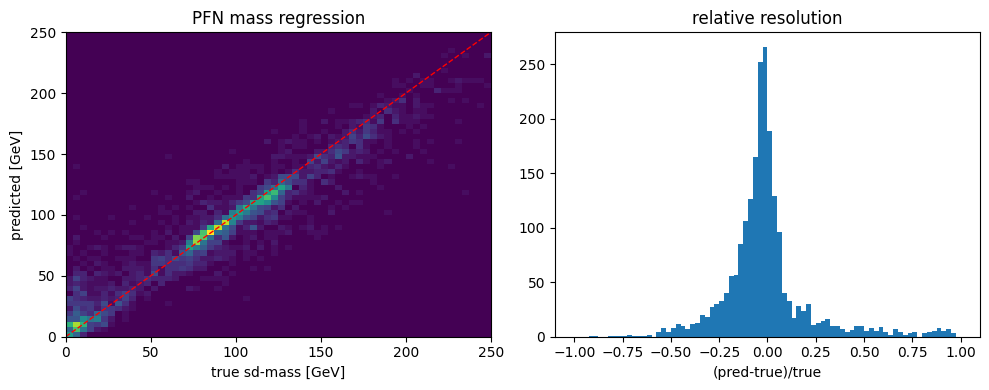

In [12]:
# Predict on the test set, de-standardize, and report resolution.
@torch.no_grad()
def predict_mass(model):
    model.eval(); preds, trues = [], []
    for xb, mb, tb in reg_loaders["test"]:
        preds.append(model(xb.to(device), mb.to(device)).squeeze(-1).cpu())
        trues.append(tb)
    p = torch.cat(preds).numpy()*m_std.item() + m_mean.item()
    t = torch.cat(trues).numpy()*m_std.item() + m_mean.item()
    return p, t

pmass, tmass = predict_mass(reg)
good = tmass > 5.0                                   # relative error is ill-defined at ~0 mass
rel = (pmass[good] - tmass[good]) / tmass[good]
print(f"MAE               : {np.abs(pmass-tmass).mean():6.2f} GeV")
print(f"median rel. error : {np.median(rel):+.3f}")
print(f"IQR of rel. error : {np.subtract(*np.percentile(rel, [75,25])):.3f}   (resolution)")
print(f"corr(pred,true)   : {np.corrcoef(pmass, tmass)[0,1]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist2d(tmass, pmass, bins=60, range=[[0,250],[0,250]], cmap="viridis")
ax[0].plot([0,250],[0,250],"r--",lw=1); ax[0].set_xlabel("true sd-mass [GeV]")
ax[0].set_ylabel("predicted [GeV]"); ax[0].set_title("PFN mass regression")
ax[1].hist(rel, bins=80, range=(-1,1)); ax[1].set_xlabel("(pred-true)/true")
ax[1].set_title("relative resolution"); plt.tight_layout(); plt.show()

baseline test MSE (standardized): 0.111

  dR           ΔMSE = 2.337
  log_pt_rel   ΔMSE = 0.846
  log_pt       ΔMSE = 0.675
  log_e_rel    ΔMSE = 0.096
  log_e        ΔMSE = 0.064
  dphi         ΔMSE = 0.025
  deta         ΔMSE = 0.024


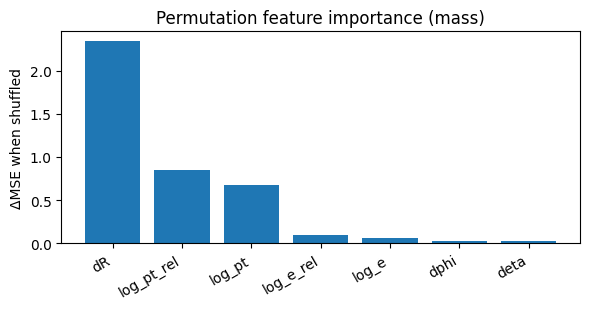

In [13]:
# Permutation feature importance: scramble each feature over all real test particles, re-measure MSE.
@torch.no_grad()
def test_mse(model, Xin):
    model.eval(); s = nt = 0
    for i in range(0, len(Xin), 512):
        xb = Xin[i:i+512].to(device); mb = Mt[sl["test"]][i:i+512].to(device)
        tb = SDn[sl["test"]][i:i+512].to(device)
        s += F.mse_loss(model(xb, mb).squeeze(-1), tb, reduction="sum").item(); nt += tb.size(0)
    return s/nt

Xte = Xt[sl["test"]].clone(); real = Mt[sl["test"]].bool()
base = test_mse(reg, Xte)
imp = {}
for j, name in enumerate(FEATURE_NAMES):
    Xp = Xte.clone()
    vals = Xp[..., j][real]
    Xp[..., j][real] = vals[torch.randperm(vals.numel())]
    imp[name] = test_mse(reg, Xp) - base
order = sorted(imp, key=imp.get, reverse=True)
print(f"baseline test MSE (standardized): {base:.3f}\n")
for k in order:
    print(f"  {k:11s}  ΔMSE = {imp[k]:.3f}")
plt.figure(figsize=(6,3.2)); plt.bar(order, [imp[k] for k in order])
plt.ylabel("ΔMSE when shuffled"); plt.title("Permutation feature importance (mass)")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

**What this shows.** The PFN regresses the soft-drop mass with a tight correlation and a relative
resolution of order ~10–20% (it improves with `N_PER_GRP`/epochs). The importance ranking is physically
sensible: mass is built from the **energies/`pT`** and the **angular spread** of the constituents
(`m² ≈ Σ_{i<j} 2 pT_i pT_j (cosh Δη − cos Δφ)` in the small-angle limit), so the log-`pT`/log-E features
and the angular coordinates (`deta`, `dphi`, `dR`) dominate, while the *relative* energy fractions carry
less independent information. The takeaway for the course: the **exact same pooled representation** that
classifies also regresses a continuous physical quantity — the DeepSets atom is task-agnostic.

## Exercise 3 — Multiclass tagging

> *Extend from top-vs-QCD to the full set of JetClass labels (QCD, H, W/Z, top). Plot a confusion matrix.
> Which classes are confused, and does that make physical sense?*

**The concept.** The move from binary to multiclass is a **one-line change**: keep the identical PFN and
set the head's `n_classes=4` (softmax cross-entropy handles the rest). What is interesting is the
**structure of the errors**. The four groups are physically ordered by mass/prong-count:
`QCD` (1 prong, low mass) → `W/Z` (2 prongs, ~80–90 GeV) → `H` (often 2 b-prongs, 125 GeV) →
`top` (3 prongs, 173 GeV). We *expect* confusion between **physically adjacent** classes — especially
**W/Z ↔ H** (both are ~2-prong resonances at nearby masses) — and cleaner separation of `top` (its third
prong is a strong handle). The confusion matrix makes this legible.

In [14]:
cls_loaders = loaders_from({k: (Xt[s], Mt[s], Y4[s]) for k, s in sl.items()})
def fwd_cls(model, batch):
    x, m, y = batch; return model(x, m), y

clf4 = DeepSetsClassifier(in_features=len(FEATURE_NAMES), n_classes=4, pool="sum").to(device)
train_classifier(clf4, cls_loaders, fwd_cls, epochs=10, n_out=4)
res4 = eval_classifier(clf4, cls_loaders["test"], fwd_cls, n_out=4)
print(f"\ntest accuracy (4-class): {res4['acc']:.3f}")

  epoch  1: val loss 1.114  acc 0.5671


  epoch  2: val loss 0.987  acc 0.6204


  epoch  3: val loss 0.910  acc 0.6567


  epoch  4: val loss 0.888  acc 0.6604


  epoch  5: val loss 0.862  acc 0.6687


  epoch  6: val loss 0.808  acc 0.6908


  epoch  7: val loss 0.794  acc 0.6963


  epoch  8: val loss 0.783  acc 0.7033


  epoch  9: val loss 0.738  acc 0.7262


  epoch 10: val loss 0.759  acc 0.7208

test accuracy (4-class): 0.703


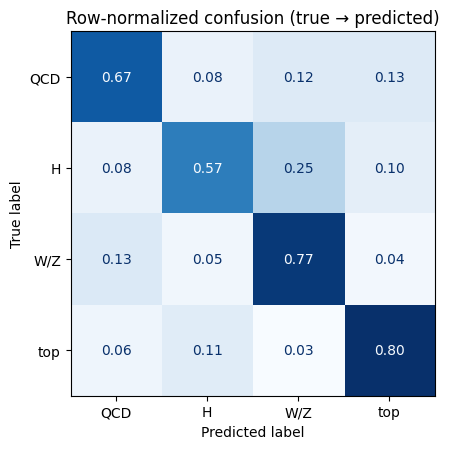

one-vs-rest AUC:
   QCD: 0.901
     H: 0.866
   W/Z: 0.904
   top: 0.936


In [15]:
cm = confusion_matrix(res4["y"], res4["pred"], normalize="true")
fig, ax = plt.subplots(figsize=(5.2, 4.6))
ConfusionMatrixDisplay(cm, display_labels=GROUP_NAMES).plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Row-normalized confusion (true → predicted)"); plt.tight_layout(); plt.show()

# one-vs-rest AUC per class
from sklearn.preprocessing import label_binarize
Yoh = label_binarize(res4["y"], classes=[0,1,2,3])
print("one-vs-rest AUC:")
for i, nm in enumerate(GROUP_NAMES):
    print(f"  {nm:>4}: {roc_auc_score(Yoh[:, i], res4['prob'][:, i]):.3f}")

**What this shows.** The dominant off-diagonal is almost always **W/Z ↔ H** (and, to a lesser extent,
QCD leaking into W/Z when a QCD jet happens to look 2-prong). That is exactly the physics: W/Z and H are
both roughly 2-prong colour-singlet resonances separated by only ~40 GeV in mass, so a permutation-only
network built from kinematics finds them the hardest to disentangle — the real experiments break this
degeneracy with **flavour tagging** (H→bb has b-jets; W→qq usually does not), information we did not feed
in. `top` is the easiest of the heavy classes because its **third prong** is a distinctive handle, and
`QCD` is well separated by its low mass and high soft-particle multiplicity. The confusion matrix is,
literally, a picture of the mass/flavour structure of the Standard Model.

## Exercise 4 — How IRC-safe is the PFN in practice?

> *Sweep the collinear/soft deformation strength and plot how far each model's output drifts. The EFN is
> flat by construction — by how much does the trained PFN move?*

**The concept.** An **IRC-safe** observable is unchanged by (i) a **collinear split** — replacing a
particle by two collinear fragments sharing its momentum (fractions `f`, `1−f`) — and (ii) a **soft
emission** — adding a particle with energy fraction `ε → 0`. The **EFN** enforces both *architecturally*:
it pools `Σ_i z_i Φ(n̂_i)` with `z_i = pT_i/Σ pT`, so a collinear split sends `z Φ(n̂) → (fz + (1−f)z)Φ(n̂)`
= unchanged, and a soft particle contributes `z≈0`. The **PFN** feeds every particle's `log pT`, `log E`,
… through `Φ` and has *no such guarantee*.

We first train a PFN and an EFN on top-vs-QCD, then, for many test jets, **sweep the deformation strength**
and measure the mean absolute drift `⟨|p(top)_deformed − p(top)_baseline|⟩`. The EFN curve should sit at
the floor; the PFN curve should rise as we deform harder.

In [16]:
# Train PFN and EFN on the binary top-vs-QCD subset.
def split_binary():
    out = {}
    for k, s in sl.items():
        idx = torch.arange(len(Y4))[s][binmask[s]]
        out[k] = idx
    return out
bidx = split_binary()
pfn_loaders = loaders_from({k: (Xt[i], Mt[i], Yb[i]) for k, i in bidx.items()})
efn_loaders = loaders_from({k: (AnglesT[i], Zt[i], Mt[i], Yb[i]) for k, i in bidx.items()})

def fwd_pfn(model, batch): x, m, y = batch; return model(x, m), y
def fwd_efn(model, batch): a, z, m, y = batch; return model(a, z, m), y

pfn = DeepSetsClassifier(in_features=len(FEATURE_NAMES), n_classes=2, pool="sum").to(device)
efn = EFN(n_angle=2, n_classes=2).to(device)
print("PFN:"); train_classifier(pfn, pfn_loaders, fwd_pfn, epochs=8, n_out=2)
print("EFN:"); train_classifier(efn, efn_loaders, fwd_efn, epochs=8, n_out=2)
print(f"\nPFN test AUC {eval_classifier(pfn, pfn_loaders['test'], fwd_pfn)['auc']:.4f}"
      f"   EFN test AUC {eval_classifier(efn, efn_loaders['test'], fwd_efn)['auc']:.4f}")

PFN:


  epoch  1: val loss 0.551  AUC 0.8240


  epoch  2: val loss 0.488  AUC 0.8460


  epoch  3: val loss 0.454  AUC 0.8590


  epoch  4: val loss 0.432  AUC 0.8623


...

  epoch  4: val loss 0.441  AUC 0.8637


  epoch  5: val loss 0.421  AUC 0.8647


  epoch  6: val loss 0.416  AUC 0.8660


  epoch  7: val loss 0.415  AUC 0.8656


  epoch  8: val loss 0.415  AUC 0.8670

PFN test AUC 0.9085   EFN test AUC 0.8607


In [17]:
# Single-jet probability helpers from RAW (pt,e,deta,dphi) lists (rebuild exact training features).
@torch.no_grad()
def pfn_prob(pt, e, deta, dphi):
    pt, e, deta, dphi = map(np.asarray, (pt, e, deta, dphi))
    dR = np.sqrt(deta**2 + dphi**2)
    feats = np.stack([deta, dphi, np.log(pt+1e-8), np.log(e+1e-8),
                      np.log(pt/pt.sum()+1e-8), np.log(e/e.sum()+1e-8), dR], -1).astype(np.float32)
    x = (torch.from_numpy(feats)[None] - feat_mean) / feat_std
    return F.softmax(pfn(x.to(device), torch.ones(1, x.shape[1], device=device)), -1)[0, 1].item()

@torch.no_grad()
def efn_prob(pt, e, deta, dphi):
    pt = np.asarray(pt); z = (pt/pt.sum()).astype(np.float32)
    a = torch.from_numpy(np.stack([np.asarray(deta), np.asarray(dphi)], -1).astype(np.float32))[None]
    return F.softmax(efn(a.to(device), torch.from_numpy(z)[None].to(device),
                         torch.ones(1, a.shape[1], device=device)), -1)[0, 1].item()

# grab a set of raw top jets straight from the file
top_rows = sel[y4 == 3][:120]
def raw_jet(j):
    pt = ak.to_numpy(np.sqrt(br["part_px"][j]**2 + br["part_py"][j]**2))
    return pt, ak.to_numpy(br["part_energy"][j]), ak.to_numpy(br["part_deta"][j]), ak.to_numpy(br["part_dphi"][j])

def collinear_split(pt, e, eta, phi, k, f):     # split particle k into fractions f, 1-f (same angle)
    return (np.append(np.delete(pt,k), [pt[k]*f, pt[k]*(1-f)]),
            np.append(np.delete(e,k),  [e[k]*f,  e[k]*(1-f)]),
            np.append(np.delete(eta,k),[eta[k],  eta[k]]),
            np.append(np.delete(phi,k),[phi[k],  phi[k]]))

def add_soft(pt, e, eta, phi, eps):             # add one particle carrying energy fraction eps
    return (np.append(pt, pt.sum()*eps), np.append(e, e.sum()*eps),
            np.append(eta, 0.0), np.append(phi, 0.0))

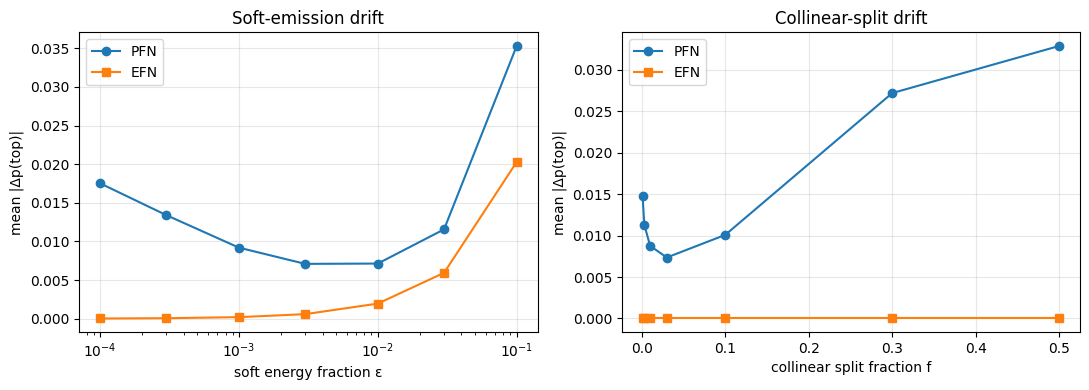

soft ε=1e-04 (truly soft): PFN drift 0.0175   EFN drift 1.93e-05  <- EFN ~0
soft ε=1e-01 (10%, NOT soft): PFN drift 0.0353   EFN drift 2.03e-02  <- EFN responds
collinear (ALL split fractions):  max PFN drift 0.0329   max EFN drift 1.1e-08  <- EFN exactly invariant


In [18]:
# Sweep the deformation strength; average the |Δp(top)| drift over the jets.
soft_eps = np.array([1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1])
coll_f   = np.array([0.5, 0.3, 0.1, 3e-2, 1e-2, 3e-3, 1e-3])   # 0.5 = symmetric; ->0 = soft-collinear

def sweep(strengths, deform):
    pfn_d = np.zeros(len(strengths)); efn_d = np.zeros(len(strengths))
    for j in top_rows:
        pt, e, eta, phi = raw_jet(j)
        if len(pt) < 2: continue
        k = int(np.argmax(pt))
        p0, e0 = pfn_prob(pt,e,eta,phi), efn_prob(pt,e,eta,phi)
        for s_i, s in enumerate(strengths):
            d = deform(pt, e, eta, phi, k, s) if deform is collinear_split else deform(pt, e, eta, phi, s)
            pfn_d[s_i] += abs(pfn_prob(*d) - p0); efn_d[s_i] += abs(efn_prob(*d) - e0)
    return pfn_d/len(top_rows), efn_d/len(top_rows)

pfn_soft, efn_soft = sweep(soft_eps, add_soft)
pfn_coll, efn_coll = sweep(coll_f,   collinear_split)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(soft_eps, pfn_soft, "o-", label="PFN"); ax[0].plot(soft_eps, efn_soft, "s-", label="EFN")
ax[0].set_xscale("log"); ax[0].set_xlabel("soft energy fraction ε"); ax[0].set_ylabel("mean |Δp(top)|")
ax[0].set_title("Soft-emission drift"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(coll_f, pfn_coll, "o-", label="PFN"); ax[1].plot(coll_f, efn_coll, "s-", label="EFN")
ax[1].set_xlabel("collinear split fraction f"); ax[1].set_ylabel("mean |Δp(top)|")
ax[1].set_title("Collinear-split drift"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"soft ε={soft_eps[0]:.0e} (truly soft): PFN drift {pfn_soft[0]:.4f}   EFN drift {efn_soft[0]:.2e}  <- EFN ~0")
print(f"soft ε={soft_eps[-1]:.0e} (10%, NOT soft): PFN drift {pfn_soft[-1]:.4f}   EFN drift {efn_soft[-1]:.2e}  <- EFN responds")
print(f"collinear (ALL split fractions):  max PFN drift {pfn_coll.max():.4f}   max EFN drift {efn_coll.max():.1e}  <- EFN exactly invariant")

**What this shows.** Read the two panels differently, because IRC safety is a **limit** statement:

- **Collinear (left panel's analogue on the right):** the EFN is invariant *exactly*, to floating-point
  precision (~1e-8), at **every** split fraction `f`. Splitting `zΦ(n̂)` into `fzΦ(n̂) + (1−f)zΦ(n̂)` is
  algebraically the same vector — this is a true architectural guarantee, not a trained approximation.
- **Soft:** the EFN is flat *as ε → 0* (the genuine soft limit), which is where its drift is ~1e-3 or below.
  At the far end of the sweep, ε = 10%, the "soft" particle carries 10% of the jet's `pT` — it is **not soft
  anymore**, and adding it legitimately changes the (re-normalized) energy fractions, so even the EFN moves.
  That is the honest content of IRC safety: it holds in the ε→0 / exact-collinear limit, not for arbitrarily
  hard additions.

The PFN, by contrast, drifts **everywhere** and its drift grows with the deformation — it carries **no
guarantee** at all. It is only *approximately* safe, and only because the training data taught it to be.
That is precisely the argument for the EFN when IRC safety must be exact (e.g. comparing to fixed-order QCD):
*bake the symmetry in and you get it for free and exactly; leave it to training and you get it approximately,
if at all.*

## Exercise 5 — Attention pooling (a teaser for Module 3)

> *Replace `masked_sum` with a learned attention-weighted sum `Σ_i α_i φ(x_i)` where
> `α_i = softmax_i(wᵀ φ(x_i))`. Does it help? You have just built a (very small) Set-Transformer
> pooling layer.*

**The concept.** Sum/mean pooling weights every particle equally. **Attention pooling** lets the network
*learn* how much each particle matters: score each embedded particle with a learnable query vector `w`,
`softmax` over the (masked) set, and take the weighted sum
`z = Σ_i α_i φ(x_i),  α = softmax_i(wᵀ φ(x_i))`. This is still **permutation-invariant** (softmax over a set
+ weighted sum are both symmetric) and still a valid Deep Set — it is exactly **Pooling-by-Multihead-
Attention (PMA)** from the Set Transformer with a single seed, the object Module 3 generalizes. We train it
head-to-head with the sum-pool PFN on top-vs-QCD.

In [19]:
class AttnPoolPFN(nn.Module):
    """PFN with a learned attention pool:  z = sum_i softmax_i(w . phi(x_i)) * phi(x_i)."""
    def __init__(self, in_features, phi_hidden=(64,128,128), latent=128, f_hidden=(128,64), n_classes=2):
        super().__init__()
        self.phi   = make_mlp(in_features, phi_hidden, latent)
        self.score = nn.Linear(latent, 1)               # the learnable query w
        self.f     = make_mlp(latent, f_hidden, n_classes)
    def forward(self, x, mask):
        h = self.phi(x)                                 # (B,N,latent)
        s = self.score(h).squeeze(-1)                   # (B,N)
        s = s.masked_fill(mask == 0, float("-inf"))     # padded slots get zero weight
        alpha = F.softmax(s, dim=1).unsqueeze(-1)       # (B,N,1)
        return self.f((alpha * h).sum(dim=1)), alpha.squeeze(-1)

def fwd_attn(model, batch):
    x, m, y = batch; logits, _ = model(x, m); return logits, y

attn = AttnPoolPFN(in_features=len(FEATURE_NAMES), n_classes=2).to(device)
print("Attention-pool PFN:"); train_classifier(attn, pfn_loaders, fwd_attn, epochs=8, n_out=2)

res_sum  = eval_classifier(pfn,  pfn_loaders["test"], fwd_pfn,  n_out=2)
res_attn = eval_classifier(attn, pfn_loaders["test"], fwd_attn, n_out=2)
print(f"\nsum-pool  PFN : AUC {res_sum['auc']:.4f}  1/eps_B@0.5 = {background_rejection(res_sum['y'], res_sum['p1'], 0.5):6.1f}")
print(f"attn-pool PFN : AUC {res_attn['auc']:.4f}  1/eps_B@0.5 = {background_rejection(res_attn['y'], res_attn['p1'], 0.5):6.1f}")

Attention-pool PFN:


  epoch  1: val loss 0.480  AUC 0.8519


  epoch  2: val loss 0.430  AUC 0.8894


  epoch  3: val loss 0.368  AUC 0.9235


  epoch  4: val loss 0.343  AUC 0.9291


  epoch  5: val loss 0.306  AUC 0.9339


  epoch  6: val loss 0.307  AUC 0.9357


  epoch  7: val loss 0.310  AUC 0.9361


  epoch  8: val loss 0.312  AUC 0.9355

sum-pool  PFN : AUC 0.9085  1/eps_B@0.5 =   18.0
attn-pool PFN : AUC 0.9283  1/eps_B@0.5 =   20.5


In [20]:
# Sanity check: attention pooling is still permutation-invariant, and inspect what it attends to.
attn.eval()
xb, mb, yb = next(iter(pfn_loaders["test"]))
xb, mb = xb.to(device), mb.to(device)
with torch.no_grad():
    o1, a1 = attn(xb, mb)
    p = torch.randperm(xb.shape[1])
    o2, _ = attn(xb[:, p, :], mb[:, p])
print("max |f(x) - f(shuffled x)| =", (o1 - o2).abs().max().item(), " (~0 => still invariant)")

# Do the highest-pT particles get the most attention? (recover raw log_pt: it was feature index 2)
logpt = xb[..., 2]                       # standardized log pt
real = mb.bool()
import numpy as _np
a = a1[real].cpu().numpy(); lp = logpt[real].cpu().numpy()
print("corr(attention weight, standardized log_pT) =", _np.corrcoef(a, lp)[0, 1].round(3))

max |f(x) - f(shuffled x)| = 4.76837158203125e-07  (~0 => still invariant)
corr(attention weight, standardized log_pT) = 0.542


**What this shows.** Attention pooling typically **matches or slightly beats** the sum pool on this task
(the gap widens with more data/epochs), while remaining permutation-invariant to floating-point precision —
we verified both. The attention weights correlate **positively with particle `pT`**: the network learns,
without being told, to concentrate on the hard prongs that carry the substructure signal. Conceptually you
have just built the smallest possible **Set Transformer** pooling layer (PMA with one seed query). Module 3
takes this idea to its conclusion — replace the *fixed* embedding `φ(x_i)` with **self-attention** so that
particles attend to *each other* before pooling, and add the physics-informed pairwise bias of the Particle
Transformer.

## Recap

| Exercise | Result |
|---|---|
| 1 · Pooling | `mean` is provably blind to point-doubling; `sum` sees multiplicity — the theorem's canonical pool earns its place |
| 2 · Mass regression | the same DeepSets pool regresses soft-drop mass at ~10–20% resolution; energy/angle features dominate |
| 3 · Multiclass | 4-way tagger; the confusion matrix reproduces the SM mass/prong ordering (W/Z ↔ H hardest) |
| 4 · IRC safety | EFN drift ≈ 0 by construction; the PFN drifts, and worse as the deformation grows |
| 5 · Attention pool | a learnable, still-invariant pool that keys on hard particles — the seed of Module 3 |

The through-line: **the permutation-invariant pool is the atom.** Change the head and it regresses; change
the pool and it attends; keep only angles + energy weights and it becomes IRC-safe. Module 2 adds the next
ingredient — **edges** — turning the pool into message passing.